# Automated PLAXIS vs Kirsch comparison

This notebook reads:

- the layered soil profile and soil properties from the CPT Excel file;
- the PLAXIS phase result sheets from the PLAXIS Excel file;
- the available soil layers and measurement depth points;
- the PLAXIS stress results and analytical Kirsch stresses.

The main improvement is that the notebook prints a clear layer/depth selection table before plotting.  
The user can then choose, for example:

```python
SELECTED_LAYER = "Sand_2"
SELECTED_DEPTH_POINT = 3
```

or:

```python
SELECTED_LAYER = "Sand_2"
SELECTED_DEPTH_POINT = "all"
```


In [1]:
# ============================================================
# CELL 1 — IMPORTS AND USER SETTINGS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)

# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------
# Use local relative paths when the notebook is in the same folder. Remember to put the diameter of the borehole in the plaxis result 
# filename, for example "CPT1-2_Linear_PLAXIS_results_R0.45.xlsx" if the borehole diameter is 0.9m (R=0.45m).

soil_file = Path(r"C:\AA_Thesis\Results\0.3m_lengkeek_output\latest_nu\CPT1-2_Linear.xlsx")
plaxis_file = Path(r"C:\AA_Thesis\Results\PLAXIS_results\Linear_elastic\nu0.25_0.35_results\CPT1-2_Linear_PLAXIS_results_R0.45.xlsx")

# ------------------------------------------------------------
# General analysis settings
# ------------------------------------------------------------

gamma_w = 10.0  # water unit weight [kN/m3]

# If True: gamma_eff = gamma - gamma_w.
# If False: gamma_eff = gamma.
USE_EFFECTIVE_UNIT_WEIGHT = True

# Radius setting:
# - None means infer radius automatically from the PLAXIS result file.
# - Give a number, for example 0.45, to force a manual value.
R_USER = None

# K0 setting:
# - "excel" tries to use K0x/K0y from the soil properties sheet when possible.
# - "constant" uses K0_DEFAULT.
K0_MODE = "constant"
K0_DEFAULT = 0.5

# Poisson's ratio setting:
# - "excel" uses v' from the soil properties sheet per layer.
# - "constant" uses NU_DEFAULT.
NU_MODE = "excel"
NU_DEFAULT = 0.3

# z rounding avoids tiny floating-point differences in exported coordinates.
Z_ROUND_DECIMALS = 3

# Skip phase_0 because it is the initial phase.
SKIP_PHASE_0 = True

# Folder for optional figure export.
SAVE_FIGURES = False
FIGURE_FOLDER = Path("figures_plaxis_kirsch")


In [2]:
# ============================================================
# CELL 2 — HELPER FUNCTIONS FOR NAMES AND NUMERIC VALUES
# ============================================================

def normalise_layer_name(name):
    """
    Make layer names comparable between the soil Excel and PLAXIS output.

    Examples:
    - 'Organic clay 1'  -> 'organic clay 1'
    - 'Organic_clay_1'  -> 'organic clay 1'
    - 'Clay & silt 1'   -> 'clay and silt 1'
    """
    return (
        str(name)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("&", "and")
        .replace("  ", " ")
    )


def safe_float(value, default=np.nan):
    """Convert a value to float; return default when conversion fails."""
    try:
        return float(value)
    except Exception:
        return default


def first_existing_column(df, candidate_columns):
    """Return the first column name from candidate_columns that exists in df."""
    for col in candidate_columns:
        if col in df.columns:
            return col
    return None


In [3]:
# ============================================================
# CELL 3 — READ SOIL PROFILE AND SOIL PROPERTIES
# ============================================================

# ------------------------------------------------------------
# Read ground profile
# ------------------------------------------------------------
profile_raw = pd.read_excel(soil_file, sheet_name="OHE Ground Profile")

# The file uses columns such as Name and BH1.
name_col = first_existing_column(profile_raw, ["Name", "layer_name", "Layer"])
z_col = first_existing_column(profile_raw, ["BH1", "z_level", "z", "Level"])

if name_col is None or z_col is None:
    raise ValueError("Could not identify layer-name and z-level columns in OHE Ground Profile.")

profile_raw = profile_raw[[name_col, z_col]].copy()
profile_raw.columns = ["layer_name", "z_level"]
profile_raw = profile_raw.dropna()

# Top of soil profile
top_rows = profile_raw[profile_raw["layer_name"].astype(str).str.strip().str.lower() == "top"]

if top_rows.empty:
    raise ValueError("Could not find row named 'Top' in OHE Ground Profile.")

ground_surface_z = float(top_rows["z_level"].iloc[0])
top_index = top_rows.index[0]

# Rows below Top are interpreted as layer bottoms
profile_layers = profile_raw.loc[top_index + 1:].copy()
profile_layers["z_level"] = profile_layers["z_level"].astype(float)

# ------------------------------------------------------------
# Read soil properties
# ------------------------------------------------------------
props = pd.read_excel(soil_file, sheet_name="Soil Properties")

if "Name" not in props.columns:
    raise ValueError("Could not find column 'Name' in Soil Properties.")

props["name_norm"] = props["Name"].apply(normalise_layer_name)

# ------------------------------------------------------------
# Build layer table with top and bottom elevations
# ------------------------------------------------------------
layers = []
current_top = ground_surface_z

for _, row in profile_layers.iterrows():
    layer_name = row["layer_name"]
    bottom_z = float(row["z_level"])

    layers.append({
        "layer_name_excel": layer_name,
        "name_norm": normalise_layer_name(layer_name),
        "top_z": current_top,
        "bottom_z": bottom_z,
        "mid_z": 0.5 * (current_top + bottom_z),
    })

    current_top = bottom_z

layers = pd.DataFrame(layers)

# Select useful property columns when available
property_columns = ["name_norm"]

for col in ["Unit weight (kN/m3)", "v'", "K0", "K0x =K0y", "K0x", "K0y"]:
    if col in props.columns:
        property_columns.append(col)

layers = layers.merge(
    props[property_columns],
    on="name_norm",
    how="left"
)

# Rename for convenience
rename_map = {
    "Unit weight (kN/m3)": "gamma",
    "v'": "nu_from_excel",
}
layers = layers.rename(columns=rename_map)

if "gamma" not in layers.columns:
    raise ValueError("Could not find unit weight column 'Unit weight (kN/m3)' in Soil Properties.")

if "nu_from_excel" not in layers.columns:
    layers["nu_from_excel"] = np.nan

# Effective unit weight
if USE_EFFECTIVE_UNIT_WEIGHT:
    layers["gamma_eff"] = layers["gamma"] - gamma_w
else:
    layers["gamma_eff"] = layers["gamma"]

# K0 handling
if "K0x" in layers.columns:
    layers["K0x_numeric"] = layers["K0x"].apply(lambda x: safe_float(x, np.nan))
else:
    layers["K0x_numeric"] = np.nan

if "K0y" in layers.columns:
    layers["K0y_numeric"] = layers["K0y"].apply(lambda x: safe_float(x, np.nan))
else:
    layers["K0y_numeric"] = np.nan

layers["K0x_used"] = np.where(
    (K0_MODE == "excel") & layers["K0x_numeric"].notna(),
    layers["K0x_numeric"],
    K0_DEFAULT
)

layers["K0y_used"] = np.where(
    (K0_MODE == "excel") & layers["K0y_numeric"].notna(),
    layers["K0y_numeric"],
    K0_DEFAULT
)

# nu handling
layers["nu_used"] = np.where(
    (NU_MODE == "excel") & layers["nu_from_excel"].notna(),
    layers["nu_from_excel"],
    NU_DEFAULT
)

print(f"Ground surface z = {ground_surface_z:.3f} m")
display(layers)


Ground surface z = -1.560 m


,layer_name_excel,name_norm,top_z,bottom_z,mid_z,gamma,nu_from_excel,K0,K0x =K0y,K0x,K0y,gamma_eff,K0x_numeric,K0y_numeric,K0x_used,K0y_used,nu_used
0,Organic clay 1,organic clay 1,-1.56,-1.74,-1.65,15.10000,0.35,F,F,1,1,5.10000,1.0,1.0,0.5,0.5,0.35
1,Silty sand 1,silty sand 1,-1.74,-2.04,-1.89,20.50000,0.25,F,F,1,1,10.50000,1.0,1.0,0.5,0.5,0.25
2,Sand 1,sand 1,-2.04,-4.46,-3.25,19.70000,0.25,F,F,1,1,9.70000,1.0,1.0,0.5,0.5,0.25
3,Peat 1,peat 1,-4.46,-5.40,-4.93,12.50000,0.35,F,F,1,1,2.50000,1.0,1.0,0.5,0.5,0.35
4,Organic clay 2,organic clay 2,-5.40,-6.16,-5.78,14.70000,0.35,F,F,1,1,4.70000,1.0,1.0,0.5,0.5,0.35
5,Peat 2,peat 2,-6.16,-7.26,-6.71,12.50000,0.35,F,F,1,1,2.50000,1.0,1.0,0.5,0.5,0.35
6,Organic clay 3,organic clay 3,-7.26,-8.10,-7.68,15.10000,0.35,F,F,1,1,5.10000,1.0,1.0,0.5,0.5,0.35
7,Clay & silt 1,clay and silt 1,-8.10,-8.88,-8.49,15.00000,0.35,F,F,1,1,5.00000,1.0,1.0,0.5,0.5,0.35
8,Peat 3,peat 3,-8.88,-9.66,-9.27,12.50000,0.35,F,F,1,1,2.50000,1.0,1.0,0.5,0.5,0.35
9,Clay & silt 2,clay and silt 2,-9.66,-10.64,-10.15,15.00000,0.35,F,F,1,1,5.00000,1.0,1.0,0.5,0.5,0.35


In [4]:
# ============================================================
# CELL 4 — VERTICAL EFFECTIVE STRESS AND LAYER LOOKUP
# ============================================================

def get_layer_row_at_z(z, layers):
    """
    Return the layer row containing elevation z.

    Coordinate convention:
    - z is elevation, negative downward.
    - top_z is less negative than bottom_z.
    """
    z = float(z)

    matches = layers[
        (z <= layers["top_z"]) &
        (z >= layers["bottom_z"])
    ]

    if not matches.empty:
        return matches.iloc[0]

    # If z is slightly outside because of rounding, return the nearest layer midpoint.
    nearest_idx = (layers["mid_z"] - z).abs().idxmin()
    return layers.loc[nearest_idx]


def sigma_v_eff_at_z(z, layers):
    """
    Calculate vertical effective stress at elevation z.

    Compression is treated as positive.
    """
    z = float(z)

    if z >= ground_surface_z:
        return 0.0

    sigv = 0.0

    for _, layer in layers.iterrows():
        top_z = float(layer["top_z"])
        bottom_z = float(layer["bottom_z"])
        gamma_eff = float(layer["gamma_eff"])

        # If the target point is above this layer, skip.
        if z >= top_z:
            continue

        # Use only the part of the layer above the target point.
        used_bottom = max(z, bottom_z)
        thickness = top_z - used_bottom

        if thickness > 0:
            sigv += gamma_eff * thickness

        # Stop once the target point is inside this layer.
        if z >= bottom_z:
            break

    return sigv


def nu_at_z(z, layers):
    """Return Poisson's ratio used for the layer containing z."""
    return float(get_layer_row_at_z(z, layers)["nu_used"])


def k0x_at_z(z, layers):
    """Return K0x used for the layer containing z."""
    return float(get_layer_row_at_z(z, layers)["K0x_used"])


def k0y_at_z(z, layers):
    """Return K0y used for the layer containing z."""
    return float(get_layer_row_at_z(z, layers)["K0y_used"])


# Quick check
check_depths = [-1.65, -3.0, -6.0, -10.0, -24.78]

for z_test in check_depths:
    layer = get_layer_row_at_z(z_test, layers)
    print(
        f"z = {z_test:7.2f} m | "
        f"layer = {layer['layer_name_excel']:<20} | "
        f"sigma_v_eff = {sigma_v_eff_at_z(z_test, layers):8.3f} kPa | "
        f"nu = {nu_at_z(z_test, layers):.3f} | "
        f"K0x = {k0x_at_z(z_test, layers):.3f} | "
        f"K0y = {k0y_at_z(z_test, layers):.3f}"
    )


z =   -1.65 m | layer = Organic clay 1       | sigma_v_eff =    0.459 kPa | nu = 0.350 | K0x = 0.500 | K0y = 0.500
z =   -3.00 m | layer = Sand 1               | sigma_v_eff =   13.380 kPa | nu = 0.250 | K0x = 0.500 | K0y = 0.500
z =   -6.00 m | layer = Organic clay 2       | sigma_v_eff =   32.712 kPa | nu = 0.350 | K0x = 0.500 | K0y = 0.500
z =  -10.00 m | layer = Clay & silt 2        | sigma_v_eff =   48.048 kPa | nu = 0.350 | K0x = 0.500 | K0y = 0.500
z =  -24.78 m | layer = Sand 2               | sigma_v_eff =  187.400 kPa | nu = 0.250 | K0x = 0.500 | K0y = 0.500


In [5]:
# ============================================================
# CELL 5 — KIRSCH SOLUTION
# ============================================================

def kirsch(r, theta, a, sigH, sigh, sigv, deltaPw, nu):
    """
    Kirsch stresses around a circular borehole.

    Inputs:
    - r      : radial distance from borehole centre [m]
    - theta  : polar angle [rad]
    - a      : borehole radius [m]
    - sigH   : major horizontal effective stress [kPa]
    - sigh   : minor horizontal effective stress [kPa]
    - sigv   : vertical effective stress [kPa]
    - deltaPw: unloading / borehole pressure change term [kPa]
    - nu     : Poisson's ratio [-]

    Output convention:
    - compression positive
    """
    r = np.asarray(r, dtype=float)
    theta = np.asarray(theta, dtype=float)

    term1 = deltaPw * (a**2 / r**2)

    sigma_rr = (
        term1
        + (sigH + sigh) / 2 * (1 - a**2 / r**2)
        + (sigH - sigh) / 2
        * (1 - 4 * a**2 / r**2 + 3 * a**4 / r**4)
        * np.cos(2 * theta)
    )

    sigma_tt = (
        -term1
        + (sigH + sigh) / 2 * (1 + a**2 / r**2)
        - (sigH - sigh) / 2
        * (1 + 3 * a**4 / r**4)
        * np.cos(2 * theta)
    )

    tau_rt = (
        - (sigH - sigh) / 2
        * (1 + 2 * a**2 / r**2 - 3 * a**4 / r**4)
        * np.sin(2 * theta)
    )

    sigma_zz = sigv - 2 * nu * (sigH - sigh) * (a**2 / r**2) * np.cos(2 * theta)

    return sigma_rr, sigma_tt, tau_rt, sigma_zz


In [6]:
# ============================================================
# CELL 6 — LOAD PLAXIS DATA AND INFER RADIUS
# ============================================================

xls = pd.ExcelFile(plaxis_file)

phase_names = [
    sheet for sheet in xls.sheet_names
    if sheet.startswith("phase_")
]

if SKIP_PHASE_0:
    phase_names = [sheet for sheet in phase_names if sheet != "phase_0"]

phase_names = sorted(phase_names, key=lambda s: int(s.split("_")[1]))

if not phase_names:
    raise ValueError("No phase sheets found in the PLAXIS result file.")

# Read the first selected phase for checks and radius inference
df_first = pd.read_excel(plaxis_file, sheet_name=phase_names[0])

required_plaxis_columns = [
    "x", "y", "z", "sigx", "sigy", "sigxy",
    "layer_name", "distance_from_wall", "radius_from_centre"
]

missing_columns = [col for col in required_plaxis_columns if col not in df_first.columns]

if missing_columns:
    raise ValueError(f"Missing required PLAXIS columns: {missing_columns}")

def infer_radius_from_plaxis(df):
    """
    Infer borehole radius from:
        radius_from_centre - distance_from_wall

    The median is used to be robust against tiny numerical variations.
    """
    radius_values = df["radius_from_centre"] - df["distance_from_wall"]
    return float(radius_values.median())

if R_USER is None:
    R = infer_radius_from_plaxis(df_first)
    radius_source = "inferred from PLAXIS file"
else:
    R = float(R_USER)
    radius_source = "manual user value"

print(f"Loaded phase sheets: {phase_names}")
print(f"Borehole radius R = {R:.3f} m ({radius_source})")


Loaded phase sheets: ['phase_1', 'phase_2', 'phase_3', 'phase_4', 'phase_5', 'phase_6', 'phase_7', 'phase_8', 'phase_9', 'phase_10', 'phase_11']
Borehole radius R = 0.450 m (inferred from PLAXIS file)


In [7]:
# ============================================================
# CELL 7 — CALCULATE PLAXIS POLAR STRESSES AND KIRSCH STRESSES
# ============================================================

def add_calculated_stresses(df, layers, R):
    """
    Add:
    - polar coordinates r/theta;
    - PLAXIS stresses converted from Cartesian to polar;
    - vertical effective stress and horizontal stress estimates;
    - Kirsch analytical stresses.

    PLAXIS compression is treated as negative, so stresses are multiplied by -1
    to obtain compression-positive results.
    """
    df = df.copy()

    x = df["x"].to_numpy(dtype=float)
    y = df["y"].to_numpy(dtype=float)
    z = df["z"].to_numpy(dtype=float)

    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)

    sigx = df["sigx"].to_numpy(dtype=float)
    sigy = df["sigy"].to_numpy(dtype=float)
    sigxy = df["sigxy"].to_numpy(dtype=float)

    sigma_rr_plx = -(
        sigx * np.cos(theta)**2
        + sigy * np.sin(theta)**2
        + 2 * sigxy * np.sin(theta) * np.cos(theta)
    )

    sigma_tt_plx = -(
        sigx * np.sin(theta)**2
        + sigy * np.cos(theta)**2
        - 2 * sigxy * np.sin(theta) * np.cos(theta)
    )

    tau_rt_plx = -(
        (sigy - sigx) * np.sin(theta) * np.cos(theta)
        + sigxy * (np.cos(theta)**2 - np.sin(theta)**2)
    )

    # Optional vertical PLAXIS stress in compression-positive convention
    if "sigz" in df.columns:
        sigma_zz_plx = -df["sigz"].to_numpy(dtype=float)
    else:
        sigma_zz_plx = np.full(len(df), np.nan)

    # Load factor
    if "load_factor" in df.columns and df["load_factor"].notna().any():
        load_factor = float(df["load_factor"].dropna().iloc[0])
    else:
        load_factor = np.nan

    sigv_arr = np.array([sigma_v_eff_at_z(zi, layers) for zi in z], dtype=float)
    nu_arr = np.array([nu_at_z(zi, layers) for zi in z], dtype=float)
    K0x_arr = np.array([k0x_at_z(zi, layers) for zi in z], dtype=float)
    K0y_arr = np.array([k0y_at_z(zi, layers) for zi in z], dtype=float)

    # In this notebook:
    # - sigH is taken as K0x * sigma_v_eff
    # - sigh is taken as K0y * sigma_v_eff
    # For isotropic horizontal stress, K0x = K0y.
    sigH_arr = K0x_arr * sigv_arr
    sigh_arr = K0y_arr * sigv_arr

    # Same unloading convention as the previous notebook:
    # deltaPw = initial minor horizontal effective stress * load factor
    deltaPw_arr = sigh_arr * load_factor

    sig_rr_k, sig_tt_k, tau_rt_k, sig_zz_k = kirsch(
        r=r,
        theta=theta,
        a=R,
        sigH=sigH_arr,
        sigh=sigh_arr,
        sigv=sigv_arr,
        deltaPw=deltaPw_arr,
        nu=nu_arr,
    )

    df["r"] = r
    df["theta"] = theta
    df["z_round"] = df["z"].round(Z_ROUND_DECIMALS)

    df["sigv_eff"] = sigv_arr
    df["K0x_used"] = K0x_arr
    df["K0y_used"] = K0y_arr
    df["nu_used"] = nu_arr
    df["sigH_eff"] = sigH_arr
    df["sigh_eff"] = sigh_arr
    df["deltaPw"] = deltaPw_arr

    df["sig_rr_plx"] = sigma_rr_plx
    df["sig_tt_plx"] = sigma_tt_plx
    df["tau_rt_plx"] = tau_rt_plx
    df["sig_zz_plx"] = sigma_zz_plx

    df["sig_rr_k"] = sig_rr_k
    df["sig_tt_k"] = sig_tt_k
    df["tau_rt_k"] = tau_rt_k
    df["sig_zz_k"] = sig_zz_k

    df = df.sort_values(by=["layer_index", "z_round", "distance_from_wall", "r"])

    return df


results = {}

for phase in phase_names:
    df_phase = pd.read_excel(plaxis_file, sheet_name=phase)
    results[phase] = add_calculated_stresses(df_phase, layers, R)

print(f"Calculated PLAXIS and Kirsch stresses for {len(results)} phases.")
display(results[phase_names[0]].head())


Calculated PLAXIS and Kirsch stresses for 11 phases.


,phase_index,phase_name,load_factor,layer_index,layer_name,distance_from_wall,radius_from_centre,x,y,z,sigx,sigy,sigz,sigxy,sigyz,sigzx,sig1,sig2,sig3,e,epsx,epsy,epsz,epsxy,epsyz,epszx,r,theta,z_round,sigv_eff,K0x_used,K0y_used,nu_used,sigH_eff,sigh_eff,deltaPw,sig_rr_plx,sig_tt_plx,tau_rt_plx,sig_zz_plx,sig_rr_k,sig_tt_k,tau_rt_k,sig_zz_k
0,1,Borehole unloading 1 - LF 1.00 [Phase_1],1,1,Organic_clay_1,0.02,0.47,0.332340,0.332340,-1.65,-0.229533,-0.229231,-0.459113,-0.000050,-0.000058,0.000017,-0.459113,-0.229557,-0.229207,0.5,-6.493594e-08,2.370158e-07,-1.446487e-07,-1.001113e-07,-1.166095e-07,3.414704e-08,0.47,0.785398,-1.65,0.459,0.5,0.5,0.35,0.2295,0.2295,0.2295,0.229432,0.229332,-0.000151,0.459113,0.2295,0.2295,-0.0,0.459
1,1,Borehole unloading 1 - LF 1.00 [Phase_1],1,1,Organic_clay_1,0.05,0.50,0.353553,0.353553,-1.65,-0.229654,-0.229612,-0.459261,0.000101,-0.000037,-0.000016,-0.459261,-0.229778,-0.229489,0.5,-1.770542e-08,2.442877e-08,-1.239592e-07,2.019073e-07,-7.332723e-08,-3.202991e-08,0.50,0.785398,-1.65,0.459,0.5,0.5,0.35,0.2295,0.2295,0.2295,0.229532,0.229734,-0.000021,0.459261,0.2295,0.2295,-0.0,0.459
2,1,Borehole unloading 1 - LF 1.00 [Phase_1],1,1,Organic_clay_1,0.10,0.55,0.388909,0.388909,-1.65,-0.229549,-0.229557,-0.459174,0.000043,-0.000011,-0.000013,-0.459174,-0.229596,-0.229510,0.5,2.378023e-08,1.528609e-08,-1.012801e-07,8.546817e-08,-2.127075e-08,-2.565178e-08,0.55,0.785398,-1.65,0.459,0.5,0.5,0.35,0.2295,0.2295,0.2295,0.229510,0.229596,0.000004,0.459174,0.2295,0.2295,-0.0,0.459
3,1,Borehole unloading 1 - LF 1.00 [Phase_1],1,1,Organic_clay_1,0.15,0.60,0.424264,0.424264,-1.65,-0.229555,-0.229566,-0.459168,0.000029,-0.000008,-0.000011,-0.459168,-0.229589,-0.229531,0.5,1.989204e-08,9.276998e-09,-9.335906e-08,5.703996e-08,-1.582462e-08,-2.121727e-08,0.60,0.785398,-1.65,0.459,0.5,0.5,0.35,0.2295,0.2295,0.2295,0.229532,0.229589,0.000005,0.459168,0.2295,0.2295,-0.0,0.459
4,1,Borehole unloading 1 - LF 1.00 [Phase_1],1,1,Organic_clay_1,0.20,0.65,0.459619,0.459619,-1.65,-0.229558,-0.229564,-0.459160,0.000020,-0.000008,-0.000008,-0.459160,-0.229581,-0.229541,0.5,1.511124e-08,8.859470e-09,-8.660811e-08,3.925754e-08,-1.592751e-08,-1.663199e-08,0.65,0.785398,-1.65,0.459,0.5,0.5,0.35,0.2295,0.2295,0.2295,0.229541,0.229581,0.000003,0.459160,0.2295,0.2295,-0.0,0.459


In [8]:
# ============================================================
# CELL 8 — PRINT AVAILABLE LAYERS AND DEPTH POINTS
# ============================================================

def create_layer_depth_summary(results, reference_phase=None):
    """
    Create a table of available soil layers and measurement depth points.

    Depth points are numbered shallow to deep:
    - point 1 = shallowest available point in that layer;
    - highest point number = deepest available point.
    """
    if reference_phase is None:
        reference_phase = phase_names[0]

    df = results[reference_phase].copy()

    group_cols = ["layer_index", "layer_name", "z_round"]

    summary = (
        df.groupby(group_cols, as_index=False)
        .agg(
            n_radial_points=("distance_from_wall", "count"),
            min_distance_from_wall=("distance_from_wall", "min"),
            max_distance_from_wall=("distance_from_wall", "max"),
            nu_used=("nu_used", "median"),
            K0x_used=("K0x_used", "median"),
            K0y_used=("K0y_used", "median"),
            sigv_eff=("sigv_eff", "median"),
        )
    )

    summary = summary.sort_values(["layer_index", "z_round"], ascending=[True, False])

    # Number depth points shallow to deep within each layer
    summary["depth_point"] = (
        summary.groupby("layer_index").cumcount() + 1
    )

    # Put user-facing columns first
    summary = summary[
        [
            "layer_index",
            "layer_name",
            "depth_point",
            "z_round",
            "n_radial_points",
            "min_distance_from_wall",
            "max_distance_from_wall",
            "nu_used",
            "K0x_used",
            "K0y_used",
            "sigv_eff",
        ]
    ]

    return summary


layer_depth_summary = create_layer_depth_summary(results)

print("Available soil layers and PLAXIS measurement depth points")
print("Depth point numbering is shallow to deep within each layer.\n")

for layer_index, df_layer in layer_depth_summary.groupby("layer_index", sort=True):
    layer_name = df_layer["layer_name"].iloc[0]
    print(f"[{int(layer_index)}] {layer_name}")

    for _, row in df_layer.iterrows():
        print(
            f"    point {int(row['depth_point'])}: "
            f"z = {row['z_round']:.3f} m | "
            f"{int(row['n_radial_points'])} radial points | "
            f"distance = {row['min_distance_from_wall']:.3f} to "
            f"{row['max_distance_from_wall']:.3f} m | "
            f"nu = {row['nu_used']:.3f}"
        )

    print()

display(layer_depth_summary)


Available soil layers and PLAXIS measurement depth points
Depth point numbering is shallow to deep within each layer.

[1] Organic_clay_1
    point 1: z = -1.650 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[2] Silty_sand_1
    point 1: z = -1.890 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.250

[3] Sand_1
    point 1: z = -3.250 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.250

[4] Peat_1
    point 1: z = -4.930 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[5] Organic_clay_2
    point 1: z = -5.780 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[6] Peat_2
    point 1: z = -6.710 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[7] Organic_clay_3
    point 1: z = -7.680 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[8] Clay_&_silt_1
    point 1: z = -8.490 m | 34 radial points | distance = 0.020 to 10.000 m | nu = 0.350

[9] Peat_3
    point 1: z = -9.270 m

,layer_index,layer_name,depth_point,z_round,n_radial_points,min_distance_from_wall,max_distance_from_wall,nu_used,K0x_used,K0y_used,sigv_eff
0,1,Organic_clay_1,1,-1.65,34,0.02,10.0,0.35,0.5,0.5,0.459000
1,2,Silty_sand_1,1,-1.89,34,0.02,10.0,0.25,0.5,0.5,2.493000
2,3,Sand_1,1,-3.25,34,0.02,10.0,0.25,0.5,0.5,15.805000
3,4,Peat_1,1,-4.93,34,0.02,10.0,0.35,0.5,0.5,28.717000
4,5,Organic_clay_2,1,-5.78,34,0.02,10.0,0.35,0.5,0.5,31.678000
5,6,Peat_2,1,-6.71,34,0.02,10.0,0.35,0.5,0.5,34.839000
6,7,Organic_clay_3,1,-7.68,34,0.02,10.0,0.35,0.5,0.5,38.356000
7,8,Clay_&_silt_1,1,-8.49,34,0.02,10.0,0.35,0.5,0.5,42.448000
8,9,Peat_3,1,-9.27,34,0.02,10.0,0.35,0.5,0.5,45.373000
9,10,Clay_&_silt_2,1,-10.15,34,0.02,10.0,0.35,0.5,0.5,48.798000


In [9]:
# ============================================================
# CELL 9 — USER SELECTION BEFORE PLOTTING
# ============================================================

# ------------------------------------------------------------
# Select the soil layer
# ------------------------------------------------------------
# You can use:
# - the PLAXIS layer name, for example "Sand_2";
# - the layer number printed above, for example 18.

SELECTED_LAYER = "Sand_2"

# ------------------------------------------------------------
# Select the depth point
# ------------------------------------------------------------
# You can use:
# - an integer, for example 3;
# - "all" to plot all depth points in the selected layer;
# - "representative" to plot the available depth closest to the layer midpoint;
# - "shallowest";
# - "deepest".

SELECTED_DEPTH_POINT = 2

# ------------------------------------------------------------
# Select phases
# ------------------------------------------------------------
# You can use:
# - "all";
# - "representative";
# - a list such as ["phase_1", "phase_4", "phase_7", "phase_9", "phase_11"].

SELECTED_PHASES = ["phase_1", "phase_4", "phase_7", "phase_9", "phase_11"]

# ------------------------------------------------------------
# Select stress components
# ------------------------------------------------------------
# Available:
# - "sig_rr" : radial stress
# - "sig_tt" : hoop stress
# - "tau_rt" : shear stress
# - "sig_zz" : vertical stress

SELECTED_STRESS_COMPONENTS = ["sig_tt", "sig_rr"]

# ------------------------------------------------------------
# Plotting layout
# ------------------------------------------------------------
# "separate" makes one figure per selected depth and stress component.
# This is usually clearest.
# "combined_depths" overlays multiple depths in one figure.

DEPTH_PLOT_LAYOUT = "separate"


In [10]:
# ============================================================
# CELL 10 — RESOLVE AND VALIDATE USER SELECTION
# ============================================================

def resolve_layer_selection(layer_depth_summary, selected_layer):
    """Resolve selected layer by name or printed layer number."""
    if isinstance(selected_layer, (int, np.integer)):
        matches = layer_depth_summary[
            layer_depth_summary["layer_index"] == int(selected_layer)
        ]
    else:
        selected_norm = normalise_layer_name(selected_layer)
        matches = layer_depth_summary[
            layer_depth_summary["layer_name"].apply(normalise_layer_name) == selected_norm
        ]

    if matches.empty:
        available = layer_depth_summary[["layer_index", "layer_name"]].drop_duplicates()
        raise ValueError(
            f"Layer not found: {selected_layer}\n"
            f"Available layers are:\n{available.to_string(index=False)}"
        )

    return int(matches["layer_index"].iloc[0]), matches["layer_name"].iloc[0]


def resolve_depth_selection(layer_depth_summary, selected_layer_index, selected_depth_point):
    """Resolve selected depth point(s) for a selected layer."""
    df_layer = layer_depth_summary[
        layer_depth_summary["layer_index"] == selected_layer_index
    ].copy()

    if df_layer.empty:
        raise ValueError(f"No depths found for layer index {selected_layer_index}.")

    if selected_depth_point == "all":
        return list(df_layer["z_round"].astype(float))

    if selected_depth_point == "shallowest":
        return [float(df_layer.sort_values("z_round", ascending=False)["z_round"].iloc[0])]

    if selected_depth_point == "deepest":
        return [float(df_layer.sort_values("z_round", ascending=True)["z_round"].iloc[0])]

    if selected_depth_point == "representative":
        layer_name = df_layer["layer_name"].iloc[0]
        layer_norm = normalise_layer_name(layer_name)

        matches = layers[layers["name_norm"] == layer_norm]

        if matches.empty:
            # Fallback: middle available depth
            depths = sorted(df_layer["z_round"].astype(float).to_list(), reverse=True)
            return [float(depths[len(depths) // 2])]

        target_mid_z = float(matches["mid_z"].iloc[0])
        depths = df_layer["z_round"].astype(float).to_numpy()
        selected_z = depths[np.argmin(np.abs(depths - target_mid_z))]
        return [float(selected_z)]

    # Integer depth point
    matches = df_layer[df_layer["depth_point"] == int(selected_depth_point)]

    if matches.empty:
        available_points = df_layer[["depth_point", "z_round"]]
        raise ValueError(
            f"Depth point {selected_depth_point} not found for layer {selected_layer_index}.\n"
            f"Available depth points are:\n{available_points.to_string(index=False)}"
        )

    return [float(matches["z_round"].iloc[0])]


def resolve_phase_selection(phase_names, selected_phases):
    """Resolve selected phases."""
    if selected_phases == "all":
        return phase_names

    if selected_phases == "representative":
        if len(phase_names) <= 4:
            return phase_names

        idx = [0, len(phase_names)//3, 2*len(phase_names)//3, len(phase_names)-1]
        return [phase_names[i] for i in sorted(set(idx))]

    missing = [phase for phase in selected_phases if phase not in phase_names]

    if missing:
        raise ValueError(
            f"Selected phases not found: {missing}\n"
            f"Available phases: {phase_names}"
        )

    return selected_phases


selected_layer_index, selected_layer_name = resolve_layer_selection(
    layer_depth_summary,
    SELECTED_LAYER
)

selected_z_values = resolve_depth_selection(
    layer_depth_summary,
    selected_layer_index,
    SELECTED_DEPTH_POINT
)

selected_phases = resolve_phase_selection(
    phase_names,
    SELECTED_PHASES
)

print("Selected plotting configuration")
print(f"  Layer index        : {selected_layer_index}")
print(f"  Layer name         : {selected_layer_name}")
print(f"  Depth point setting: {SELECTED_DEPTH_POINT}")
print(f"  z-values           : {selected_z_values}")
print(f"  Phases             : {selected_phases}")
print(f"  Stress components  : {SELECTED_STRESS_COMPONENTS}")
print(f"  Radius R           : {R:.3f} m")


Selected plotting configuration
  Layer index        : 16
  Layer name         : Sand_2
  Depth point setting: 2
  z-values           : [-24.78]
  Phases             : ['phase_1', 'phase_4', 'phase_7', 'phase_9', 'phase_11']
  Stress components  : ['sig_tt', 'sig_rr']
  Radius R           : 0.450 m


In [18]:
# ============================================================
# CELL 11 — PLOTTING FUNCTIONS
# ============================================================

stress_labels = {
    "sig_rr": "Radial stress σrr [kPa]",
    "sig_tt": "Hoop stress σθθ [kPa]",
    "tau_rt": "Shear stress τrθ [kPa]",
    "sig_zz": "Vertical stress σzz [kPa]",
}

stress_titles = {
    "sig_rr": "Radial stress",
    "sig_tt": "Hoop stress",
    "tau_rt": "Shear stress",
    "sig_zz": "Vertical stress",
}


def filter_phase_layer_depth(df, layer_name, selected_z, z_tolerance=10**(-Z_ROUND_DECIMALS)):
    """Filter one phase result to selected layer and selected z-level."""
    df = df.copy()
    df["z_round"] = df["z"].round(Z_ROUND_DECIMALS)

    return df[
        (df["layer_name"] == layer_name)
        & (np.isclose(df["z_round"], selected_z, atol=z_tolerance))
    ].copy()

def plot_radial_hoop_stress_together_for_depth(
    results,
    selected_layer_name,
    selected_z,
    selected_phases,
    save=False,
    figure_folder=Path("figures_plaxis_kirsch"),
):
    """
    Plot radial stress and hoop stress in one figure.

    x-axis:
    - normalized distance from borehole wall = distance_from_wall / R

    y-axis:
    - stress [kPa]
    """
    plt.figure(figsize=(11, 7))

    component_info = {
        "sig_rr": {
            "label": "Radial stress σrr",
            "marker": "o",
        },
        "sig_tt": {
            "label": "Hoop stress σθθ",
            "marker": "s",
        },
    }

    plotted_anything = False

    for phase in selected_phases:
        df = results[phase]
        df_z = filter_phase_layer_depth(df, selected_layer_name, selected_z)
        df_z = df_z.sort_values("distance_from_wall")

        if df_z.empty:
            print(f"Warning: no data for {phase}, {selected_layer_name}, z={selected_z:.3f}")
            continue

        plotted_anything = True

        phase_lf = (
            df_z["load_factor"].dropna().iloc[0]
            if df_z["load_factor"].notna().any()
            else np.nan
        )

        phase_label = f"{phase}, LF={phase_lf:.2f}" if np.isfinite(phase_lf) else phase

        # Normalised x-axis: distance from borehole wall divided by borehole radius
        x_norm = df_z["distance_from_wall"] / R

        for comp, info in component_info.items():

            plx_col = f"{comp}_plx"
            kirsch_col = f"{comp}_k"

            plt.plot(
                x_norm,
                df_z[plx_col],
                marker=info["marker"],
                markersize=3,
                linewidth=1.4,
                alpha=0.80,
                label=f"PLAXIS {info['label']} | {phase_label}",
            )

            plt.plot(
                x_norm,
                df_z[kirsch_col],
                linestyle="--",
                linewidth=1.6,
                alpha=0.95,
                label=f"Kirsch {info['label']} | {phase_label}",
            )

    if not plotted_anything:
        plt.close()
        print(f"No data plotted for {selected_layer_name}, z={selected_z:.3f}.")
        return

    plt.xlabel("Normalized distance from borehole wall, d/R [-]")
    plt.ylabel("Stress [kPa]")
    plt.title(
        f"Radial and hoop stress: PLAXIS vs Kirsch\n"
        f"{selected_layer_name}, z = {selected_z:.3f} m, R = {R:.3f} m"
    )

    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    if save:
        figure_folder.mkdir(parents=True, exist_ok=True)

        safe_layer = selected_layer_name.replace(" ", "_").replace("/", "_")
        filename = (
            f"stress_radial_hoop_{safe_layer}_"
            f"z_{selected_z:.3f}_R_{R:.3f}.png"
        )

        path = figure_folder / filename
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()

def plot_stress_component_for_depth(
    results,
    selected_layer_name,
    selected_z,
    selected_phases,
    stress_component,
    save=False,
    figure_folder=Path("figures_plaxis_kirsch"),
):
    """
    Plot one stress component for one selected layer and one selected depth.
    """
    plx_col = f"{stress_component}_plx"
    kirsch_col = f"{stress_component}_k"

    if plx_col not in results[selected_phases[0]].columns:
        raise ValueError(f"Column not found: {plx_col}")

    if kirsch_col not in results[selected_phases[0]].columns:
        raise ValueError(f"Column not found: {kirsch_col}")

    plt.figure(figsize=(10, 6))

    plotted_anything = False

    for phase in selected_phases:
        df = results[phase]
        df_z = filter_phase_layer_depth(df, selected_layer_name, selected_z)
        df_z = df_z.sort_values("distance_from_wall")

        if df_z.empty:
            print(f"Warning: no data for {phase}, {selected_layer_name}, z={selected_z:.3f}")
            continue

        plotted_anything = True

        phase_lf = df_z["load_factor"].dropna().iloc[0] if df_z["load_factor"].notna().any() else np.nan
        phase_label = f"{phase} LF={phase_lf:.2f}" if np.isfinite(phase_lf) else phase

        x_norm = df_z["distance_from_wall"] / R

        plt.plot(
            x_norm,
            df_z[plx_col],
            marker="o",
            markersize=3,
            linewidth=1.4,
            alpha=0.75,
            label=f"PLAXIS {phase_label}",
        )

        plt.plot(
            x_norm,
            df_z[kirsch_col],
            linestyle="--",
            linewidth=1.6,
            alpha=0.95,
            label=f"Kirsch {phase_label}",
        )

    if not plotted_anything:
        plt.close()
        print(f"No data plotted for {selected_layer_name}, z={selected_z:.3f}, {stress_component}.")
        return

    ylabel = stress_labels.get(stress_component, stress_component)
    title_component = stress_titles.get(stress_component, stress_component)

    plt.xlabel("Normalised radius r/R [-] from borehole centre")
    plt.ylabel(ylabel)
    plt.title(
        f"{title_component}: PLAXIS vs Kirsch\n"
        f"{selected_layer_name}, z = {selected_z:.3f} m, R = {R:.3f} m"
    )
    plt.ylim(0, 190)

    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    if save:
        figure_folder.mkdir(parents=True, exist_ok=True)
        safe_layer = selected_layer_name.replace(" ", "_").replace("/", "_")
        filename = (
            f"{stress_component}_{safe_layer}_"
            f"z_{selected_z:.3f}_R_{R:.3f}.png"
        )
        path = figure_folder / filename
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()


def plot_stress_component_combined_depths(
    results,
    selected_layer_name,
    selected_z_values,
    selected_phases,
    stress_component,
    save=False,
    figure_folder=Path("figures_plaxis_kirsch"),
):
    """
    Plot multiple depth points in one figure.

    This can be useful, but can also become visually busy.
    For report figures, separate figures are usually clearer.
    """
    plx_col = f"{stress_component}_plx"
    kirsch_col = f"{stress_component}_k"

    plt.figure(figsize=(11, 7))

    plotted_anything = False

    for selected_z in selected_z_values:
        for phase in selected_phases:
            df = results[phase]
            df_z = filter_phase_layer_depth(df, selected_layer_name, selected_z)
            df_z = df_z.sort_values("distance_from_wall")

            if df_z.empty:
                continue

            plotted_anything = True

            x_norm = df_z["distance_from_wall"] / R

            plt.plot(
                x_norm,
                df_z[plx_col],
                marker="o",
                markersize=2.5,
                linewidth=1.1,
                alpha=0.7,
                label=f"PLAXIS {phase}, z={selected_z:.2f}",
            )

            plt.plot(
                x_norm,
                df_z[kirsch_col],
                linestyle="--",
                linewidth=1.2,
                alpha=0.9,
                label=f"Kirsch {phase}, z={selected_z:.2f}",
            )

    if not plotted_anything:
        plt.close()
        print(f"No data plotted for {selected_layer_name}, {stress_component}.")
        return

    ylabel = stress_labels.get(stress_component, stress_component)
    title_component = stress_titles.get(stress_component, stress_component)

    plt.xlabel("Normalised radius r/R [-] from borehole centre")
    plt.ylabel(ylabel)
    plt.title(
        f"{title_component}: PLAXIS vs Kirsch\n"
        f"{selected_layer_name}, multiple depths, R = {R:.3f} m"
    )
    plt.ylim(0, 190)
    plt.grid(True)
    plt.legend(fontsize=7, ncol=2)
    plt.tight_layout()

    if save:
        figure_folder.mkdir(parents=True, exist_ok=True)
        safe_layer = selected_layer_name.replace(" ", "_").replace("/", "_")
        filename = f"{stress_component}_{safe_layer}_combined_depths_R_{R:.3f}.png"
        path = figure_folder / filename
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()


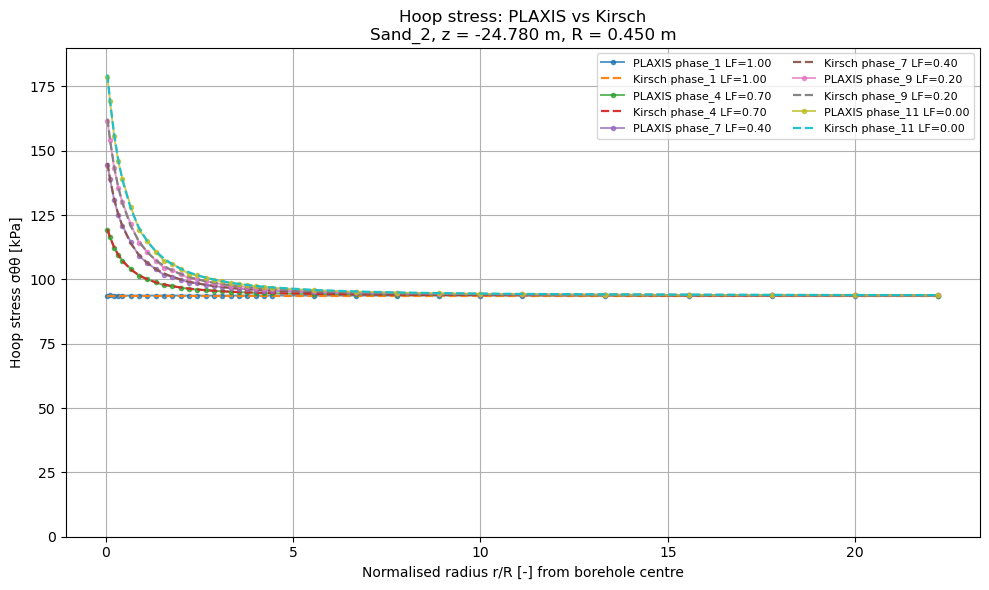

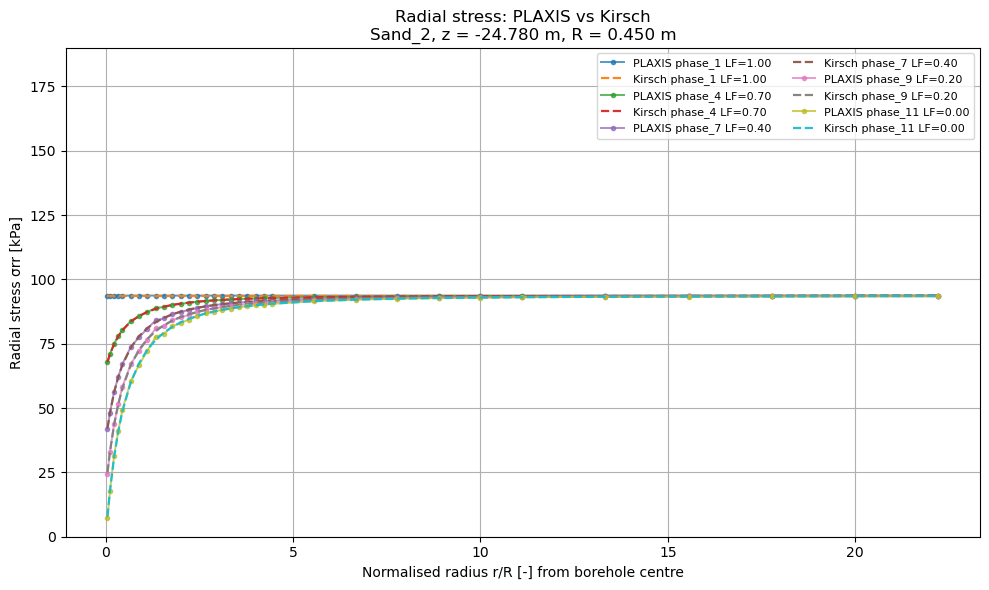

In [19]:
# ============================================================
# CELL 12 — CREATE THE SELECTED FIGURES
# ============================================================

if DEPTH_PLOT_LAYOUT == "separate":
    for stress_component in SELECTED_STRESS_COMPONENTS:
        for selected_z in selected_z_values:
            plot_stress_component_for_depth(
                results=results,
                selected_layer_name=selected_layer_name,
                selected_z=selected_z,
                selected_phases=selected_phases,
                stress_component=stress_component,
                save=SAVE_FIGURES,
                figure_folder=FIGURE_FOLDER,
            )

elif DEPTH_PLOT_LAYOUT == "combined_depths":
    for stress_component in SELECTED_STRESS_COMPONENTS:
        plot_stress_component_combined_depths(
            results=results,
            selected_layer_name=selected_layer_name,
            selected_z_values=selected_z_values,
            selected_phases=selected_phases,
            stress_component=stress_component,
            save=SAVE_FIGURES,
            figure_folder=FIGURE_FOLDER,
        )

else:
    raise ValueError("DEPTH_PLOT_LAYOUT must be 'separate' or 'combined_depths'.")


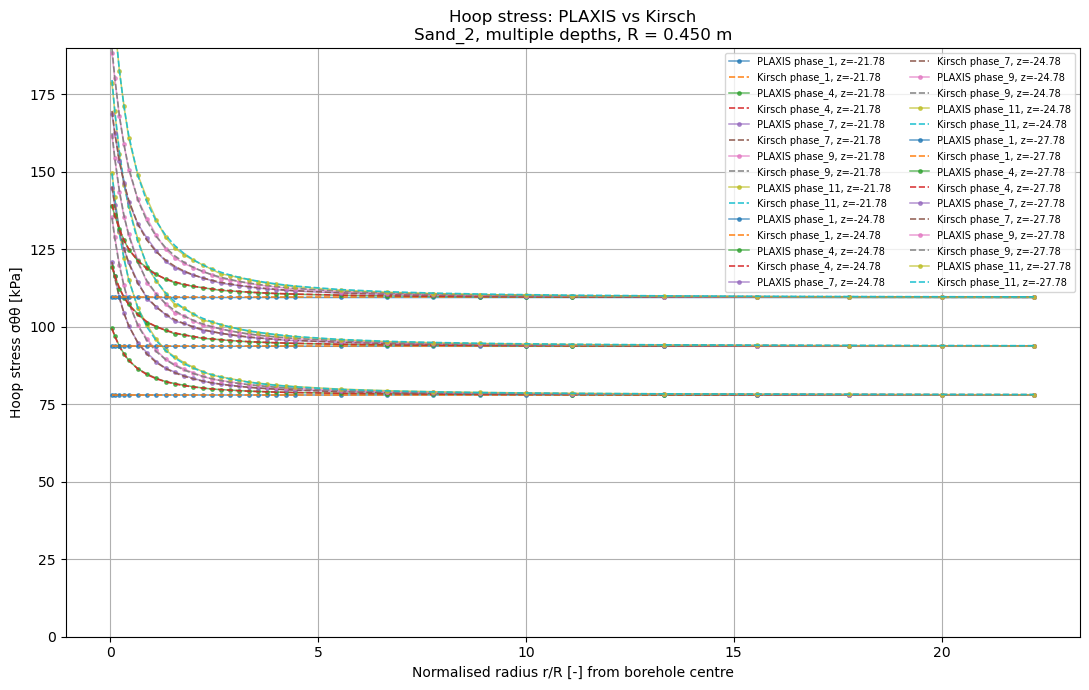

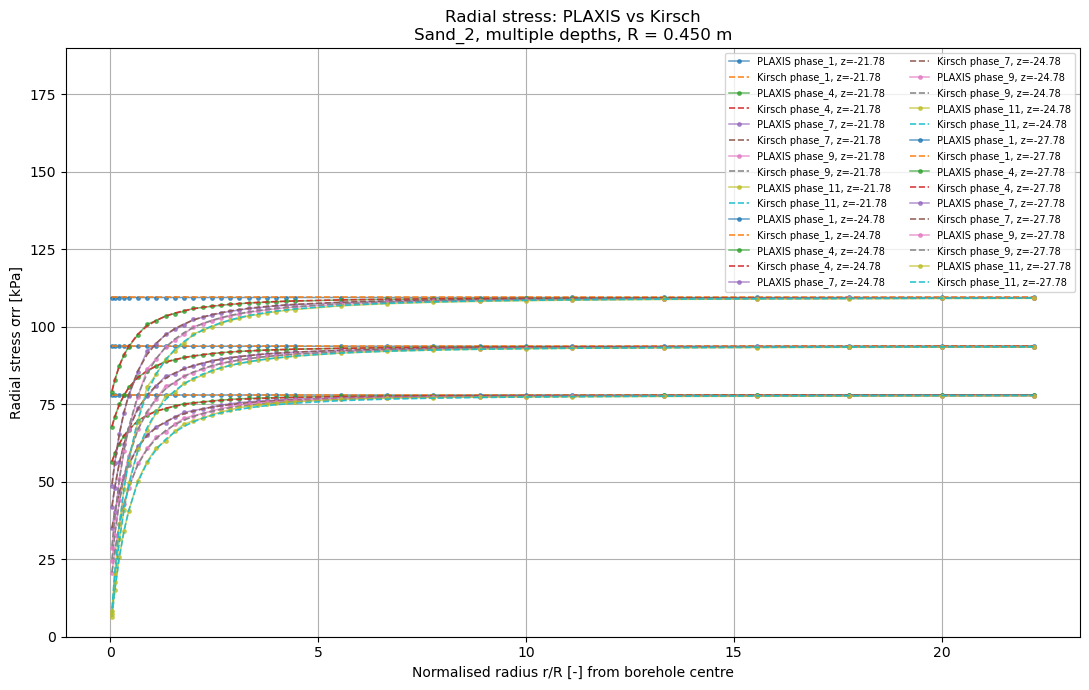

In [20]:
# ============================================================
# CELL 13 — OPTIONAL: PLOT ALL DEPTH POINTS OF THE SELECTED LAYER
# ============================================================

# This cell is useful when you first want to inspect whether all depth
# points in a layer behave similarly.

PLOT_ALL_DEPTHS_NOW = True

if PLOT_ALL_DEPTHS_NOW:
    all_z_values_for_layer = resolve_depth_selection(
        layer_depth_summary,
        selected_layer_index,
        "all"
    )

    for stress_component in SELECTED_STRESS_COMPONENTS:
        plot_stress_component_combined_depths(
            results=results,
            selected_layer_name=selected_layer_name,
            selected_z_values=all_z_values_for_layer,
            selected_phases=selected_phases,
            stress_component=stress_component,
            save=SAVE_FIGURES,
            figure_folder=FIGURE_FOLDER,
        )


In [14]:
# ============================================================
# CELL 14 — OPTIONAL: EXPORT THE LAYER/DEPTH SUMMARY
# ============================================================

EXPORT_SUMMARY = False
SUMMARY_FILE = Path("plaxis_layer_depth_summary.xlsx")

if EXPORT_SUMMARY:
    layer_depth_summary.to_excel(SUMMARY_FILE, index=False)
    print(f"Exported: {SUMMARY_FILE}")
